## 02. RFM Baseline Reproduction (Chen et al. 2012)
Reproduces the RFM + K-means baseline using `valid_purchase_lines` persisted from `preprocessing.ipynb`.

In [1]:
import pandas as pd

valid_purchase_lines = pd.read_csv("../data/processed/valid_purchase_lines.csv")
customer_features_rfm = pd.read_csv("../data/processed/customer_features_rfm.csv")

print(valid_purchase_lines.shape)
print(customer_features_rfm.shape)
customer_features_rfm.head()

(349203, 15)
(3920, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12747,2,11,4196.01
2,12748,0,209,33053.19
3,12749,3,5,4090.88
4,12820,3,4,942.34


,Recency,Frequency,Monetary
count,3920.000000,3920.000000,3920.000000
mean,91.742092,4.246429,1858.424654
std,99.533485,7.199202,7478.631256
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,298.185000
50%,50.000000,2.000000,644.975000
75%,142.000000,5.000000,1571.285000
max,373.000000,209.000000,259657.300000


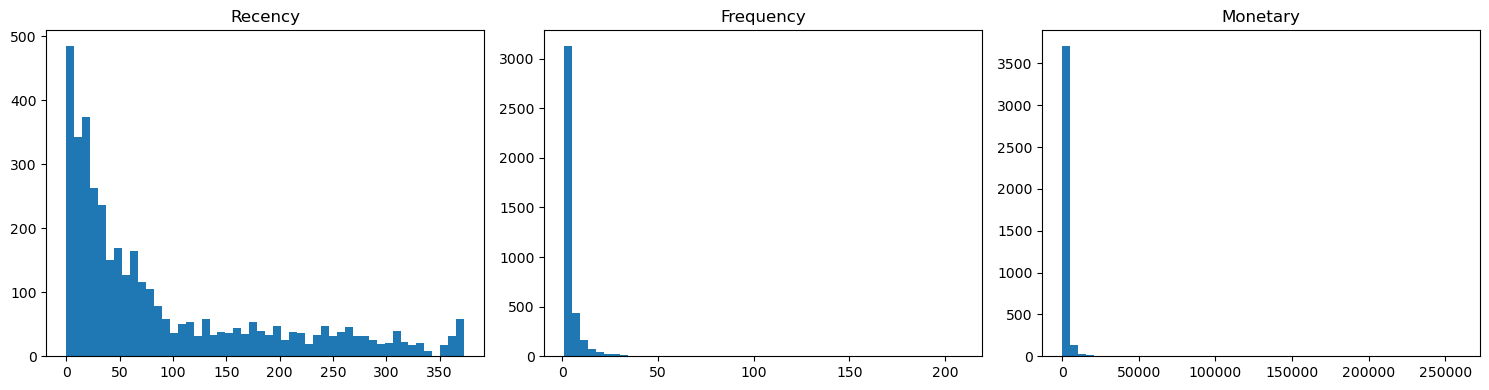

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    axes[list(['Recency','Frequency','Monetary']).index(col)].hist(customer_features_rfm[col], bins=50)
    ax.set_title(col)
plt.tight_layout()

customer_features_rfm[['Recency','Frequency','Monetary']].describe()

In [3]:
# how many customers are "one-and-done" early buyers, driving that tail bump?

one_time_early = customer_features_rfm[(customer_features_rfm['Frequency'] == 1) & (customer_features_rfm['Recency'] > 300)]
print(one_time_early.shape[0], "customers bought once and haven't returned in 300+ days")

198 customers bought once and haven't returned in 300+ days


,Recency,Frequency,Monetary
count,3.920000e+03,3.920000e+03,3.920000e+03
mean,3.987740e-17,2.904706e-16,3.516461e-16
std,1.000128e+00,1.000128e+00,1.000128e+00
min,-2.748403e+00,-9.574905e-01,-4.004447e+00
25%,-6.572134e-01,-9.574905e-01,-6.747839e-01
50%,9.628043e-02,-3.631397e-01,-5.617742e-02
75%,8.422246e-01,6.529098e-01,6.587338e-01
max,1.537807e+00,5.864515e+00,4.763099e+00


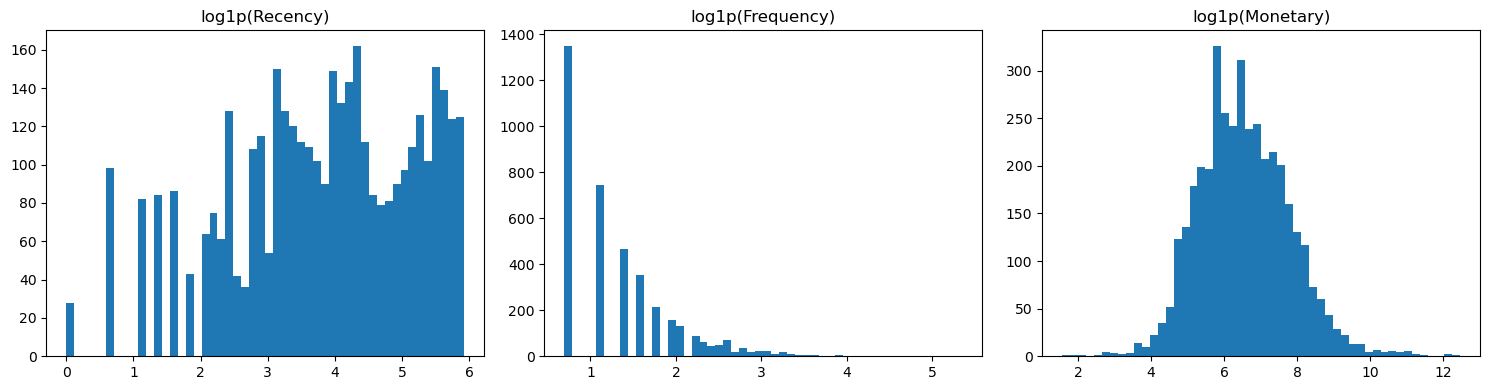

In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler

# ---- FS0: raw RFM (paper-aligned baseline, no transform) ----
FS0 = customer_features_rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']].copy()

# ---- FS1: log1p transform + scaling comparison ----
FS1_log = FS0.copy()
for col in ['Recency', 'Frequency', 'Monetary']:
    FS1_log[col] = np.log1p(FS1_log[col])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    ax.hist(FS1_log[col], bins=50)
    ax.set_title(f"log1p({col})")
plt.tight_layout()

# Compare StandardScaler vs RobustScaler on the log-transformed data
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

FS1_standard = FS1_log.copy()
FS1_standard[['Recency','Frequency','Monetary']] = std_scaler.fit_transform(FS1_log[['Recency','Frequency','Monetary']])

FS1_robust = FS1_log.copy()
FS1_robust[['Recency','Frequency','Monetary']] = rob_scaler.fit_transform(FS1_log[['Recency','Frequency','Monetary']])

FS1_standard[['Recency','Frequency','Monetary']].describe()

In [6]:
from scipy import stats

# Skewness after log1p, before scaling — quantifies what we saw visually
for col in ['Recency', 'Frequency', 'Monetary']:
    print(f"{col}: skew after log1p = {stats.skew(FS1_log[col]):.3f}")

# Compare how many "outlier" points remain post-scaling under each scaler,
# using a simple >3 std / >3 IQR-equivalent rule as a concrete, documented criterion
for name, df_scaled in [('StandardScaler', FS1_standard), ('RobustScaler', FS1_robust)]:
    outlier_flags = (df_scaled[['Recency','Frequency','Monetary']].abs() > 3).any(axis=1)
    print(f"{name}: {outlier_flags.sum()} customers (of {len(df_scaled)}) have |value| > 3 in at least one dimension")

Recency: skew after log1p = -0.464
Frequency: skew after log1p = 1.182
Monetary: skew after log1p = 0.373
StandardScaler: 59 customers (of 3920) have |value| > 3 in at least one dimension
RobustScaler: 9 customers (of 3920) have |value| > 3 in at least one dimension


In [7]:
FS0.to_csv("../data/processed/FS0_raw_rfm.csv", index=False)
FS1_robust.to_csv("../data/processed/FS1_log_robust_rfm.csv", index=False)

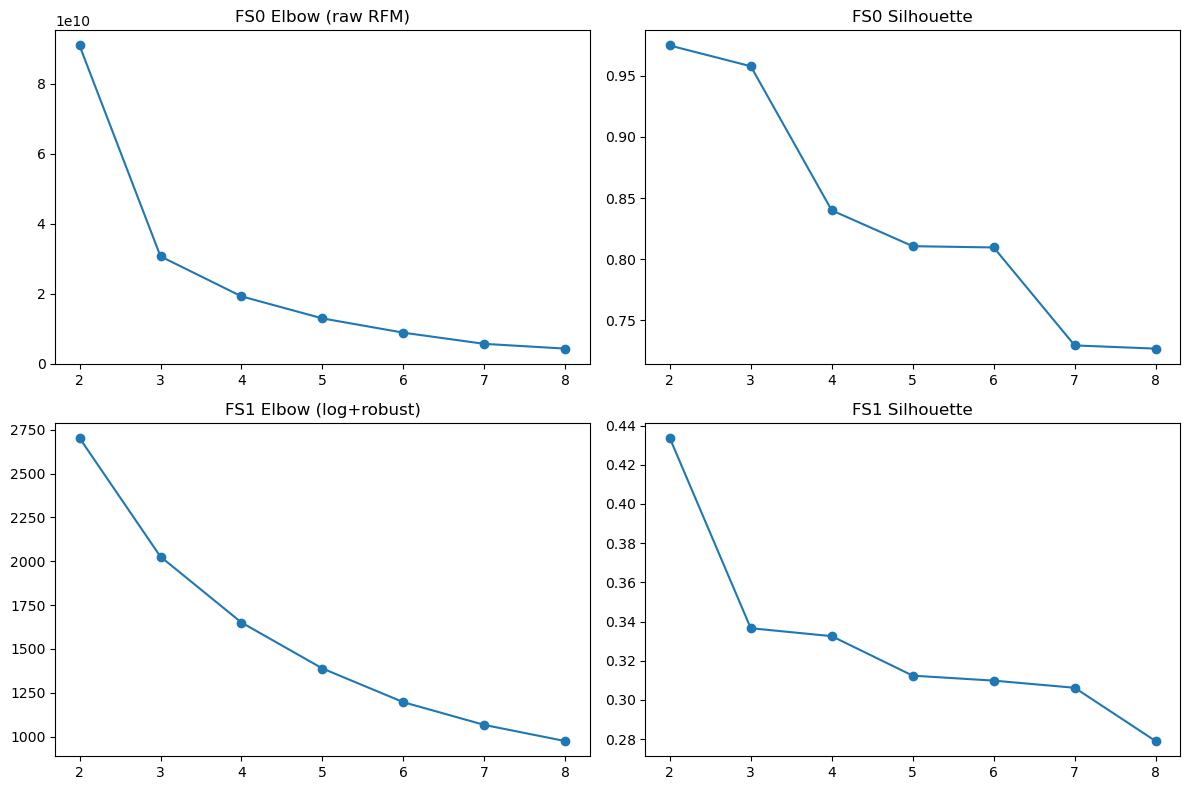

k=2: FS0 inertia=90996630132.2 sil=0.975 | FS1 inertia=2703.5 sil=0.434
k=3: FS0 inertia=30698865801.6 sil=0.958 | FS1 inertia=2026.5 sil=0.337
k=4: FS0 inertia=19268516686.1 sil=0.840 | FS1 inertia=1650.9 sil=0.333
k=5: FS0 inertia=12960148737.0 sil=0.811 | FS1 inertia=1388.7 sil=0.312
k=6: FS0 inertia=8879778310.5 sil=0.810 | FS1 inertia=1196.5 sil=0.310
k=7: FS0 inertia=5681431904.3 sil=0.729 | FS1 inertia=1066.8 sil=0.306
k=8: FS0 inertia=4323434538.1 sil=0.727 | FS1 inertia=974.6 sil=0.279


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def elbow_silhoutte_scan(X, k_range = range(2, 9)):
    inertias = []
    silhouettes = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, labels))
    return list(k_range), inertias, silhouettes

k_range = range(2, 9)
X0 = FS0[['Recency','Frequency','Monetary']].values
X1 = FS1_robust[['Recency','Frequency','Monetary']].values

ks, inertias0, sil0 = elbow_silhoutte_scan(X0, k_range)
_, inertias1, sil1 = elbow_silhoutte_scan(X1, k_range)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(ks, inertias0, marker='o'); axes[0,0].set_title("FS0 Elbow (raw RFM)")
axes[0,1].plot(ks, sil0, marker='o'); axes[0,1].set_title("FS0 Silhouette")
axes[1,0].plot(ks, inertias1, marker='o'); axes[1,0].set_title("FS1 Elbow (log+robust)")
axes[1,1].plot(ks, sil1, marker='o'); axes[1,1].set_title("FS1 Silhouette")
plt.tight_layout()
plt.show()

for k, i0, s0, i1, s1 in zip(ks, inertias0, sil0, inertias1, sil1):
    print(f"k={k}: FS0 inertia={i0:.1f} sil={s0:.3f} | FS1 inertia={i1:.1f} sil={s1:.3f}")

## K-Selection

- **FS0 (raw, unscaled RFM)** produced misleadingly high silhouette scores (0.81–0.97) - an artifact of Monetary's scale (up to 259,657) dominating the distance metric, not genuine cluster separation. Not used for k-selection; kept only as the "no scaling" baseline for comparison.
- **FS1 (log1p + RobustScaler)** silhouette scores are in a realistic range (0.28–0.43) with no sharp elbow, decreasing smoothly from k=2 to k=8 - consistent with RFM segments existing on a continuum rather than as cleanly separated clusters.
- Statistically, k=2/3 are favored by silhouette, but the paper (Chen et al.) explicitly chose k=5 over lower k for business interpretability, not statistical optimality.
- **Decision:** fit both k=3 (closer to the statistical plateau) and k=5 (matches paper, tests interpretability trade-off) on FS1, and compare.

In [9]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)

FS1_robust['Cluster_k3'] = kmeans_3.fit_predict(FS1_robust[['Recency', 'Frequency', 'Monetary']])
FS1_robust['Cluster_k5'] = kmeans_5.fit_predict(FS1_robust[['Recency', 'Frequency', 'Monetary']])

# Bring back the ORIGINAL (untransformed) RFM values for interpretation —
# cluster on log/scaled space, but always profile in real-world units (Section 17.3 practice)
FS1_profiled = FS1_robust.merge(
    customer_features_rfm[['CustomerID','Recency','Frequency','Monetary']],
    on='CustomerID', suffixes=('_scaled', '')
)

print("=== k=3 cluster sizes ===")
print(FS1_profiled['Cluster_k3'].value_counts().sort_index())
print("\n=== k=3 cluster profiles (real RFM units) ===")
print(FS1_profiled.groupby('Cluster_k3')[['Recency','Frequency','Monetary']].agg(['median','mean','min','max']))

print("\n=== k=5 cluster sizes ===")
print(FS1_profiled['Cluster_k5'].value_counts().sort_index())
print("\n=== k=5 cluster profiles (real RFM units) ===")
print(FS1_profiled.groupby('Cluster_k5')[['Recency','Frequency','Monetary']].agg(['median','mean','min','max']))

=== k=3 cluster sizes ===
Cluster_k3
0    1660
1    1549
2     711
Name: count, dtype: int64

=== k=3 cluster profiles (real RFM units) ===
           Recency                      Frequency                      \
            median        mean min  max    median       mean min  max   
Cluster_k3                                                              
0            157.0  163.703012   3  373       1.0   1.328313   1    6   
1             32.0   49.142027   0  358       3.0   3.380245   1   12   
2              8.0   16.541491   0  372       9.0  12.946554   1  209   

            Monetary                                  
              median         mean     min        max  
Cluster_k3                                            
0            266.125   307.132591    3.75    2002.40  
1            939.780  1134.683630  150.61    6617.65  
2           3509.430  7057.045851  742.43  259657.30  

=== k=5 cluster sizes ===
Cluster_k5
0     314
1     771
2     850
3    1062
4     923
Nam

In [10]:
total_monetary = FS1_profiled['Monetary'].sum()

for k_col in ['Cluster_k3', 'Cluster_k5']:
    print(f"=== {k_col}: % of customers vs % of total sales ===")
    summary = FS1_profiled.groupby(k_col).agg(
        n_customers=('CustomerID','count'),
        total_monetary=('Monetary','sum')
    )
    summary['pct_customers'] = (summary['n_customers'] / summary['n_customers'].sum() * 100).round(1)
    summary['pct_sales'] = (summary['total_monetary'] / total_monetary * 100).round(1)
    print(summary[['n_customers','pct_customers','total_monetary','pct_sales']])
    print()

=== Cluster_k3: % of customers vs % of total sales ===
            n_customers  pct_customers  total_monetary  pct_sales
Cluster_k3                                                       
0                  1660           42.3      509840.101        7.0
1                  1549           39.5     1757624.943       24.1
2                   711           18.1     5017559.600       68.9

=== Cluster_k5: % of customers vs % of total sales ===
            n_customers  pct_customers  total_monetary  pct_sales
Cluster_k5                                                       
0                   314            8.0     3801613.270       52.2
1                   771           19.7      282433.370        3.9
2                   850           21.7     1678838.850       23.0
3                  1062           27.1      266977.651        3.7
4                   923           23.5     1255161.503       17.2



In [11]:
import os
os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/models", exist_ok=True)
import joblib

# Save cluster assignments + profiles
FS1_profiled.to_csv("../results/tables/rfm_cluster_assignments.csv", index=False)

# Save fitted models
joblib.dump(kmeans_3, "../results/models/kmeans_k3_fs1.joblib")
joblib.dump(kmeans_5, "../results/models/kmeans_k5_fs1.joblib")

print("Saved cluster assignments and models.")

Saved cluster assignments and models.
